Duplicate rows removed: 0
Outlier rows detected: 84


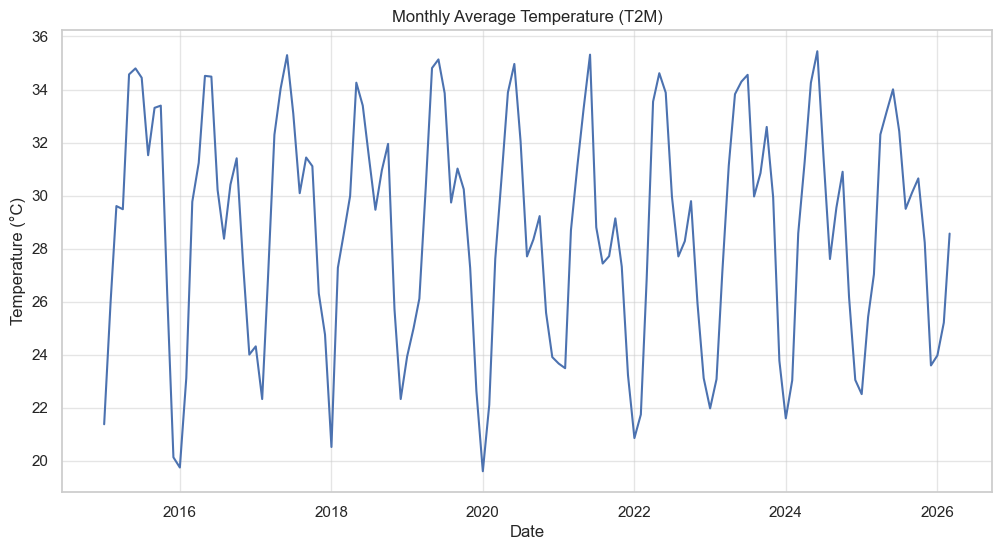

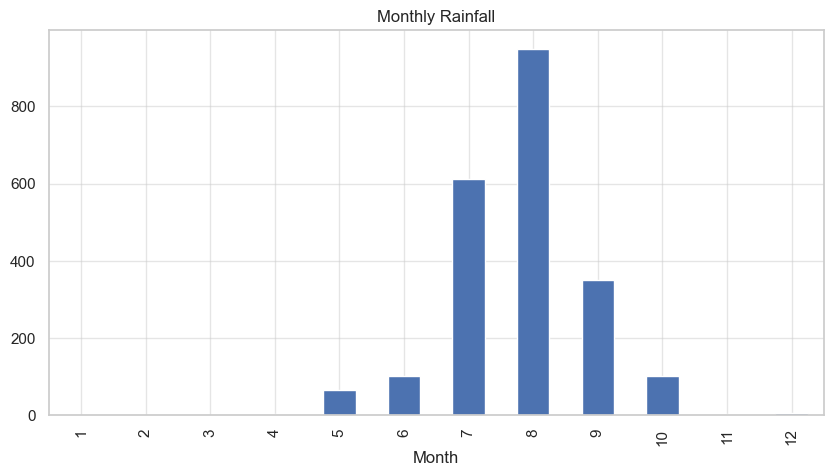

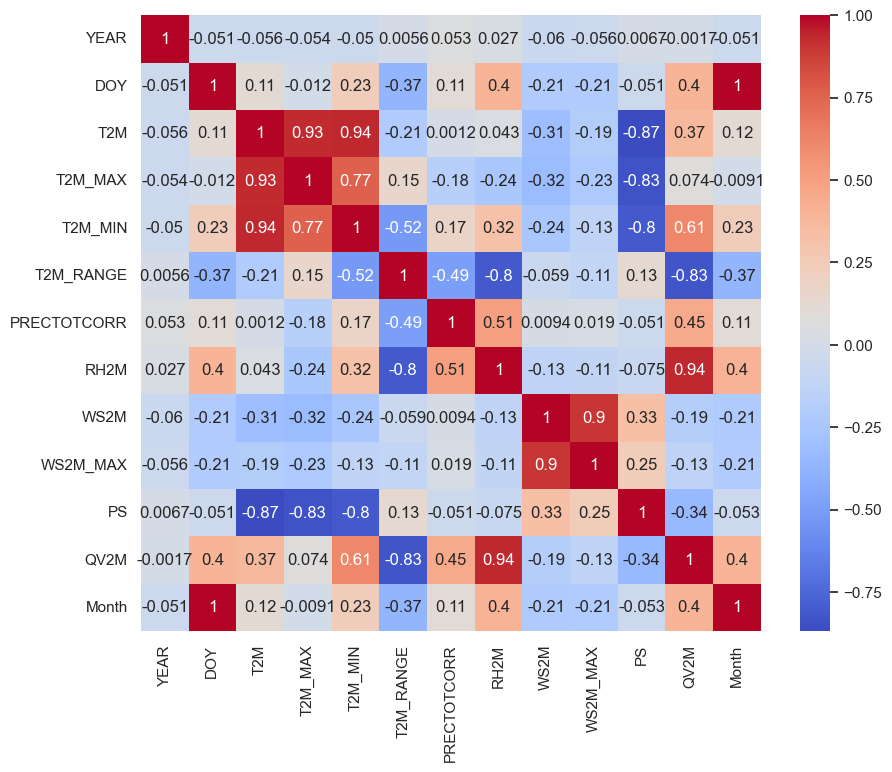

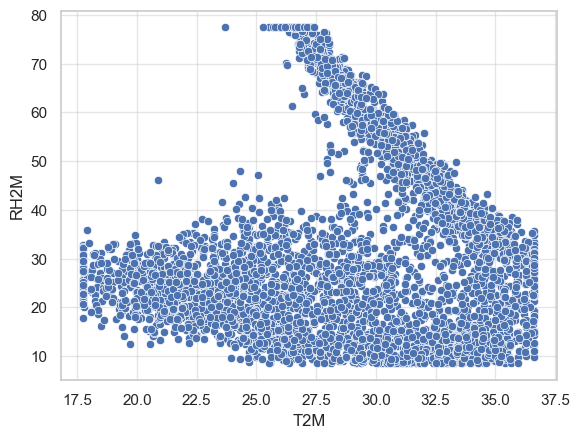

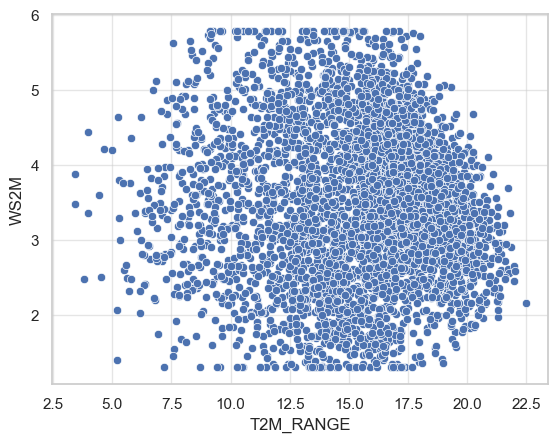

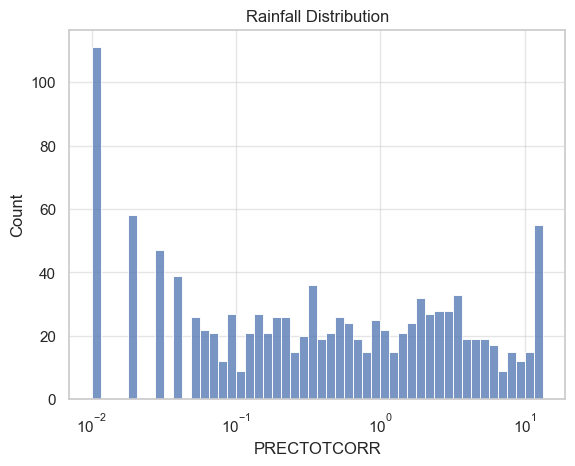

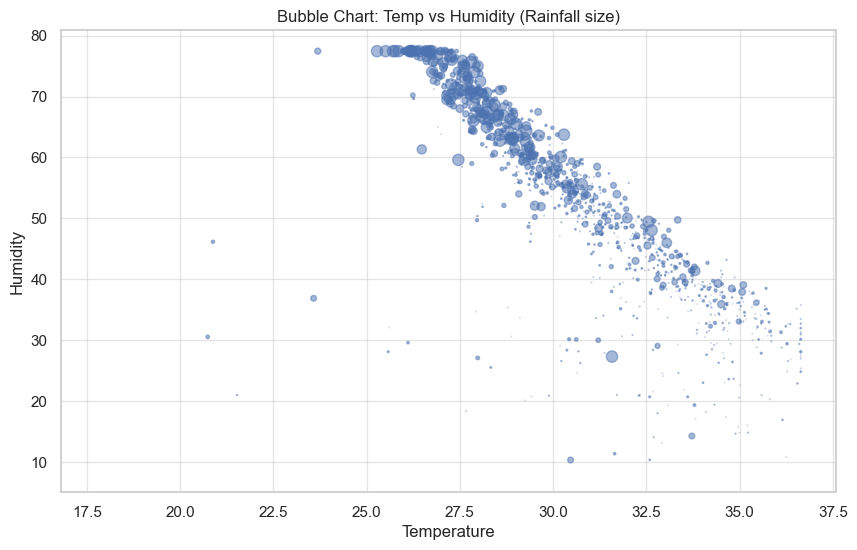

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")

country = "sudan"

df = pd.read_csv("sudan.csv")

# Add country column
df["Country"] = country

# Replace NASA missing sentinel
df = df.replace(-999, np.nan)

# Create datetime from YEAR + DOY
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract month
df["Month"] = df["Date"].dt.month

dup_count = df.duplicated().sum()
df = df.drop_duplicates()

print("Duplicate rows removed:", dup_count)
df.describe()

missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Percent": missing_pct
}).sort_values("Percent", ascending=False)

missing_report

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z = (df[cols] - df[cols].mean()) / df[cols].std()

outliers = (np.abs(z) > 3).any(axis=1)

print("Outlier rows detected:", outliers.sum())

#dicession
df[cols] = df[cols].clip(lower=df[cols].quantile(0.01),
                        upper=df[cols].quantile(0.99),
                        axis=1)

#handling messing value

# Drop rows with >30% missing
threshold = int(df.shape[1] * 0.7)
df = df.dropna(thresh=threshold)

# Forward fill weather variables
df = df.sort_values("Date")
df.ffill(inplace=True)

#exporting clean data
os.makedirs("data", exist_ok=True)
df.to_csv("data/sudan_clean.csv", index=False)


#Time serious Analaysis

monthly_temp = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()
monthly_temp["Date"] = pd.to_datetime(monthly_temp["YEAR"].astype(str) + "-" + monthly_temp["Month"].astype(str))

plt.figure(figsize=(12,6))
plt.plot(monthly_temp["Date"], monthly_temp["T2M"])
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

#Annotation
max_row = monthly_temp.loc[monthly_temp["T2M"].idxmax()]
min_row = monthly_temp.loc[monthly_temp["T2M"].idxmin()]

#Rainfall
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar", figsize=(10,5), title="Monthly Rainfall")
plt.show()

#correlation analysis
#import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

#scaterplote
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.show()

df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")
plt.show()

#distribution analysis
#histogram
sns.histplot(df["PRECTOTCORR"], bins=50, log_scale=True)
plt.title("Rainfall Distribution")
plt.show()
#boblechart
plt.figure(figsize=(10,6))
plt.scatter(df["T2M"], df["RH2M"],
            s=df["PRECTOTCORR"]*5,
            alpha=0.5)

plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Bubble Chart: Temp vs Humidity (Rainfall size)")
plt.show()

